# 네트워크 침입 탐지 — MLflow Pipeline v4

## 가설 H4: 희소 클래스 가중치가 Infilteration 오탐을 키운다

v3의 LightGBM `class_weight="balanced"`는 `Infilteration` Recall을 높였지만 정상 트래픽 2,854건을 오탐했습니다.
v4에서는 데이터 샘플, 분할, 피처, LightGBM 파라미터를 고정하고 **Infilteration 가중치만** 변경합니다.

- 후보: balanced 가중치의 1.00 / 0.75 / 0.50 / 0.25배
- 1차 지표: Benign 제외 공격 클래스 Weighted F1
- 안전조건: Infilteration Recall ≥ 0.40
- 진단 지표: Infilteration Precision/Recall/F1, Benign → Infilteration FP
- 결과 격리: `outputs/v4/`, MLflow run `v4_*`

데이터의 원래 클래스 철자인 `Infilteration`은 제출 호환성을 위해 변경하지 않고 동적으로 감지합니다.


In [1]:
from pathlib import Path
import csv
import json
import os
import tempfile
import time
import warnings

import duckdb
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import seaborn as sns
from lightgbm import LGBMClassifier
from openpyxl import load_workbook
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

HYPOTHESIS_ID = "v4"
HYPOTHESIS = "reduce_infilteration_false_positives_with_targeted_class_weight"
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

WORK_ROOT = Path("/home/jovyan/work")
cwd = Path.cwd()
PROJECT_NAME = cwd.parent.name if cwd.name == "notebooks" else "network-classification"
PROJECT_DIR = WORK_ROOT / PROJECT_NAME

DATA_BASES = [WORK_ROOT / "datasets", Path("/home/jovyan/data")]
SUPPORTED_RAW = {".csv", ".xlsx", ".parquet"}

def has_train_file(raw_dir: Path) -> bool:
    return raw_dir.exists() and any(
        p.is_file()
        and p.suffix.lower() in SUPPORTED_RAW
        and p.stem.lower().startswith("train")
        for p in raw_dir.iterdir()
    )

preferred = [base / PROJECT_NAME for base in DATA_BASES]
DATA_ROOT = next((p for p in preferred if has_train_file(p / "raw")), None)

if DATA_ROOT is None:
    matches = []
    for base in DATA_BASES:
        if base.exists():
            matches.extend(
                raw_dir.parent
                for raw_dir in base.glob("*/raw")
                if has_train_file(raw_dir)
            )
    matches = list(dict.fromkeys(matches))
    if len(matches) != 1:
        raise RuntimeError(f"학습 데이터 프로젝트를 하나로 결정할 수 없습니다: {matches}")
    DATA_ROOT = matches[0]

RAW_DIR = DATA_ROOT / "raw"
INTERIM_DIR = DATA_ROOT / "interim"
PROCESSED_DIR = DATA_ROOT / "processed"
EXTERNAL_DIR = DATA_ROOT / "external"
OUTPUT_DIR = PROJECT_DIR / "outputs" / HYPOTHESIS_ID

for path in [INTERIM_DIR, PROCESSED_DIR, EXTERNAL_DIR, OUTPUT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

ID_COL = "unique_id"
TARGET = "Label"
DROP_COLS = ["Timestamp"]
CAT_FEATURES = ["Dst Port", "Protocol"]
TRAIN_SAMPLE = 250_000
VALID_SIZE = 0.20
USE_TEMPORAL_FEATURES = False
MIN_INFILTRATION_RECALL = 0.40

MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "http://mlflow:5000")
EXPERIMENT_NAME = f"{PROJECT_NAME}-ids-{HYPOTHESIS_ID}"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print("Notebook      :", cwd)
print("Project       :", PROJECT_NAME)
print("Data root     :", DATA_ROOT)
print("Output        :", OUTPUT_DIR)
print("MLflow        :", MLFLOW_TRACKING_URI)
print("Experiment    :", EXPERIMENT_NAME)
print("Hypothesis    :", HYPOTHESIS)


2026/08/15 15:03:12 INFO mlflow.tracking.fluent: Experiment with name 'network-classification-ids-v4' does not exist. Creating a new experiment.


Notebook      : /home/jovyan/work/network-classification/notebooks
Project       : network-classification
Data root     : /home/jovyan/work/datasets/ 📁 network-classification
Output        : /home/jovyan/work/network-classification/outputs/v4
MLflow        : http://mlflow:5000
Experiment    : network-classification-ids-v4
Hypothesis    : reduce_infilteration_false_positives_with_targeted_class_weight


## 1. RAW 탐색 및 Parquet 준비

기존 Parquet을 재사용하되 RAW보다 오래된 경우 자동으로 다시 생성합니다.


In [2]:
SUPPORTED = {".csv", ".xlsx", ".parquet"}

def find_raw_file(kind: str):
    priority = [
        f"{kind}_saved.parquet", f"{kind}_saved.csv", f"{kind}_saved.xlsx",
        f"{kind}.parquet", f"{kind}.csv", f"{kind}.xlsx",
    ]
    for name in priority:
        path = RAW_DIR / name
        if path.exists():
            return path
    candidates = [
        p for p in sorted(RAW_DIR.glob(f"{kind}*"))
        if p.is_file() and p.suffix.lower() in SUPPORTED
    ]
    return candidates[0] if candidates else None

TRAIN_RAW = find_raw_file("train")
TEST_RAW = find_raw_file("test")
if TRAIN_RAW is None:
    raise FileNotFoundError(f"Train 파일이 없습니다: {RAW_DIR}")

print("Train raw:", TRAIN_RAW)
print("Test raw :", TEST_RAW)


Train raw: /home/jovyan/work/datasets/ 📁 network-classification/raw/train_saved.csv
Test raw : /home/jovyan/work/datasets/ 📁 network-classification/raw/test_saved.csv


In [3]:
def sql_path(path: Path) -> str:
    return str(path).replace("'", "''")

def parquet_expr(path: Path) -> str:
    return f"read_parquet('{sql_path(path)}')"

def csv_to_parquet(csv_path: Path, parquet_path: Path):
    parquet_path.parent.mkdir(parents=True, exist_ok=True)
    with duckdb.connect() as con:
        con.execute(f'''COPY (
            SELECT * FROM read_csv_auto(
                '{sql_path(csv_path)}', HEADER=TRUE, SAMPLE_SIZE=-1
            )
        ) TO '{sql_path(parquet_path)}' (FORMAT PARQUET, COMPRESSION ZSTD)''')

def xlsx_to_csv_stream(xlsx_path: Path, csv_path: Path):
    wb = load_workbook(xlsx_path, read_only=True, data_only=True)
    ws = wb[wb.sheetnames[0]]
    rows = ws.iter_rows(values_only=True)
    header = next(rows)
    count = 0
    with open(csv_path, "w", newline="", encoding="utf-8-sig") as handle:
        writer = csv.writer(handle)
        writer.writerow(header)
        for count, row in enumerate(rows, start=1):
            writer.writerow(row)
            if count % 100_000 == 0:
                print(f"  {count:,} rows converted")
    wb.close()
    print(f"Excel streaming 완료: {count:,} rows")

def ensure_parquet(raw_path: Path | None, output_name: str):
    if raw_path is None:
        return None
    if raw_path.suffix.lower() == ".parquet":
        return raw_path

    target = INTERIM_DIR / output_name
    if target.exists() and target.stat().st_mtime >= raw_path.stat().st_mtime:
        print("[재사용]", target)
        return target
    if target.exists():
        print("[갱신] RAW가 더 최신입니다:", target)

    if raw_path.suffix.lower() == ".csv":
        csv_to_parquet(raw_path, target)
    elif raw_path.suffix.lower() == ".xlsx":
        with tempfile.TemporaryDirectory(dir=str(INTERIM_DIR)) as tmpdir:
            tmp_csv = Path(tmpdir) / f"{raw_path.stem}.csv"
            xlsx_to_csv_stream(raw_path, tmp_csv)
            csv_to_parquet(tmp_csv, target)
    else:
        raise ValueError(f"지원하지 않는 형식: {raw_path.suffix}")
    return target

TRAIN_PARQUET = ensure_parquet(TRAIN_RAW, "train.parquet")
TEST_PARQUET = ensure_parquet(TEST_RAW, "test.parquet")
print("Train parquet:", TRAIN_PARQUET)
print("Test parquet :", TEST_PARQUET)


[재사용] /home/jovyan/work/datasets/ 📁 network-classification/interim/train.parquet
[재사용] /home/jovyan/work/datasets/ 📁 network-classification/interim/test.parquet
Train parquet: /home/jovyan/work/datasets/ 📁 network-classification/interim/train.parquet
Test parquet : /home/jovyan/work/datasets/ 📁 network-classification/interim/test.parquet


## 2. 전체 구조 확인 및 고정 샘플 로딩

In [4]:
with duckdb.connect() as con:
    train_rows = con.execute(
        f"SELECT COUNT(*) FROM {parquet_expr(TRAIN_PARQUET)}"
    ).fetchone()[0]
    train_schema = con.execute(
        f"DESCRIBE SELECT * FROM {parquet_expr(TRAIN_PARQUET)}"
    ).df()
    class_counts = con.execute(f'''
        SELECT "{TARGET}" AS label, COUNT(*) AS count
        FROM {parquet_expr(TRAIN_PARQUET)}
        GROUP BY "{TARGET}" ORDER BY count DESC
    ''').df()
    test_rows = None if TEST_PARQUET is None else con.execute(
        f"SELECT COUNT(*) FROM {parquet_expr(TEST_PARQUET)}"
    ).fetchone()[0]

if TARGET not in train_schema["column_name"].tolist():
    raise KeyError(f"학습 데이터에 {TARGET!r} 컬럼이 없습니다")
class_counts["ratio"] = class_counts["count"] / class_counts["count"].sum()
print(f"Train rows: {train_rows:,}")
print("Test rows :", None if test_rows is None else f"{test_rows:,}")
display(class_counts)


Train rows: 4,638,804
Test rows : 1,159,701


,label,count,ratio
0,Benign,3191824,0.688070
1,DDOS,550194,0.118607
2,DoS,518077,0.111683
3,Brute Force,305045,0.065759
4,Infilteration,73664,0.015880


In [5]:
def load_train_sample(path: Path, n_rows: int | None):
    with duckdb.connect() as con:
        src = parquet_expr(path)
        total = con.execute(f"SELECT COUNT(*) FROM {src}").fetchone()[0]
        if n_rows is None or n_rows >= total:
            return con.execute(f"SELECT * FROM {src}").df()
        return con.execute(f'''
            SELECT * FROM {src}
            USING SAMPLE reservoir({int(n_rows)} ROWS)
            REPEATABLE ({RANDOM_STATE})
        ''').df()

train_df = load_train_sample(TRAIN_PARQUET, TRAIN_SAMPLE)
print("Loaded:", train_df.shape)
print(f"Memory: {train_df.memory_usage(deep=True).sum() / 1024**2:,.1f} MB")
display(train_df[TARGET].value_counts().to_frame("count"))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loaded: (250000, 43)
Memory: 114.9 MB


,count
Label,
Benign,171743
DDOS,29839
DoS,27765
Brute Force,16588
Infilteration,4065


## 3. v3와 동일한 IDS 파생변수

In [6]:
def add_features(df: pd.DataFrame, use_temporal: bool = False):
    df = df.copy()
    flag_cols = [
        "SYN Flag Cnt", "ACK Flag Cnt", "RST Flag Cnt",
        "FIN Flag Cnt", "URG Flag Cnt", "PSH Flag Cnt",
    ]
    if all(c in df.columns for c in flag_cols):
        values = {
            c: pd.to_numeric(df[c], errors="coerce").fillna(0).astype(float)
            for c in flag_cols
        }
        syn, ack = values["SYN Flag Cnt"], values["ACK Flag Cnt"]
        rst, fin = values["RST Flag Cnt"], values["FIN Flag Cnt"]
        urg, psh = values["URG Flag Cnt"], values["PSH Flag Cnt"]
        total_flags = syn + ack + rst + fin + urg + psh + 1.0
        df["SYN_ACK_ratio"] = (syn + 1) / (ack + 1)
        df["RST_ACK_ratio"] = (rst + 1) / (ack + 1)
        df["SYN_RST_over_ACK_FIN"] = (syn + rst + 1) / (ack + fin + 1)
        df["ACK_SYN_ratio"] = (ack + 1) / (syn + 1)
        df["URG_ACK_ratio"] = (urg + 1) / (ack + 1)
        df["SYN_share"] = (syn + 1) / total_flags
        df["RST_share"] = (rst + 1) / total_flags

    if use_temporal:
        needed = ["Timestamp", "Flow Pkts/s", "Tot Fwd Pkts"]
        if all(c in df.columns for c in needed):
            work = df.copy()
            work["_ts"] = pd.to_datetime(work["Timestamp"], errors="coerce")
            work = work.sort_values("_ts", kind="stable")
            work["dt_prev"] = work["_ts"].diff().dt.total_seconds().fillna(0.0)
            flow_rate = pd.to_numeric(work["Flow Pkts/s"], errors="coerce").fillna(0)
            fwd_pkts = pd.to_numeric(work["Tot Fwd Pkts"], errors="coerce").fillna(0)
            window = 1000
            work["roll_dt_mean"] = work["dt_prev"].rolling(window, min_periods=1).mean()
            work["roll_pkt_std"] = flow_rate.rolling(window, min_periods=1).std().fillna(0)
            work["roll_fwd_std"] = fwd_pkts.rolling(window, min_periods=1).std().fillna(0)
            work = work.sort_index()
            for column in ["dt_prev", "roll_dt_mean", "roll_pkt_std", "roll_fwd_std"]:
                df[column] = work[column]

    numeric = df.select_dtypes(include=[np.number]).columns
    df[numeric] = df[numeric].replace([np.inf, -np.inf], np.nan)
    return df

train_df = add_features(train_df, USE_TEMPORAL_FEATURES)
print("Feature engineered:", train_df.shape)


Feature engineered: (250000, 50)


## 4. 고정 Train/Validation 분할과 전처리

In [7]:
drop_for_x = [TARGET] + [c for c in DROP_COLS if c in train_df.columns]
X = train_df.drop(columns=drop_for_x, errors="ignore")
y = train_df[TARGET].astype(str)
X = X.drop(columns=[ID_COL], errors="ignore")

cat_features = [c for c in CAT_FEATURES if c in X.columns]
num_features = [c for c in X.columns if c not in cat_features]
for column in cat_features:
    X[column] = X[column].astype("string")

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=VALID_SIZE, stratify=y, random_state=RANDOM_STATE
)

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("scaler", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])
preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_features),
    ("cat", categorical_pipe, cat_features),
])

classes = sorted(y_train.unique().tolist())
attack_classes = [c for c in classes if c != "Benign"]
infiltration_candidates = {"infiltration", "infilteration"}
INFILTRATION_LABEL = next(
    (c for c in classes if c.strip().lower() in infiltration_candidates), None
)
if INFILTRATION_LABEL is None:
    raise KeyError(f"Infiltration 계열 클래스를 찾지 못했습니다: {classes}")

print("Train:", X_train.shape, "Valid:", X_valid.shape)
print("Classes:", classes)
print("Detected infiltration label:", repr(INFILTRATION_LABEL))


Train: (200000, 47) Valid: (50000, 47)
Classes: ['Benign', 'Brute Force', 'DDOS', 'DoS', 'Infilteration']
Detected infiltration label: 'Infilteration'


## 5. 평가 및 MLflow 기록

v3에서 빠졌던 희소 클래스 지표와 정상→희소 클래스 오탐 수를 명시적으로 기록합니다.


In [8]:
def evaluate_predictions(y_true, y_pred):
    metrics = {
        "weighted_f1_attacks": float(f1_score(
            y_true, y_pred, labels=attack_classes,
            average="weighted", zero_division=0,
        )),
        "macro_f1_attacks": float(f1_score(
            y_true, y_pred, labels=attack_classes,
            average="macro", zero_division=0,
        )),
        "accuracy": float(accuracy_score(y_true, y_pred)),
    }
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[INFILTRATION_LABEL],
        average=None, zero_division=0,
    )
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)
    metrics.update({
        "infilteration_precision": float(precision[0]),
        "infilteration_recall": float(recall[0]),
        "infilteration_f1": float(f1[0]),
        "benign_to_infilteration_fp": int(np.sum(
            (y_true_arr == "Benign") & (y_pred_arr == INFILTRATION_LABEL)
        )),
        "infilteration_to_benign_fn": int(np.sum(
            (y_true_arr == INFILTRATION_LABEL) & (y_pred_arr == "Benign")
        )),
        "predicted_infilteration": int(np.sum(y_pred_arr == INFILTRATION_LABEL)),
    })
    return metrics

def save_eval_artifacts(y_true, y_pred, model_name):
    safe = model_name.lower().replace(" ", "_").replace("/", "_")
    report_path = OUTPUT_DIR / f"{safe}_classification_report.csv"
    pd.DataFrame(classification_report(
        y_true, y_pred, labels=classes,
        output_dict=True, zero_division=0,
    )).T.to_csv(report_path, encoding="utf-8-sig")

    cm = confusion_matrix(y_true, y_pred, labels=classes)
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set(title=f"Confusion Matrix — {model_name}",
           xlabel="Predicted", ylabel="Actual")
    plt.tight_layout()
    cm_path = OUTPUT_DIR / f"{safe}_confusion_matrix.png"
    fig.savefig(cm_path, dpi=140, bbox_inches="tight")
    plt.close(fig)
    return report_path, cm_path

def run_experiment(model_name, class_weight, inf_multiplier):
    estimator = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        max_depth=-1,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multiclass",
        class_weight=class_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )
    pipeline = Pipeline([
        ("preprocess", clone(preprocess)),
        ("model", estimator),
    ])
    started = time.time()
    run_name = f"{HYPOTHESIS_ID}_{model_name}"
    with mlflow.start_run(run_name=run_name) as run:
        mlflow.set_tags({
            "project": PROJECT_NAME,
            "hypothesis_id": HYPOTHESIS_ID,
            "hypothesis": HYPOTHESIS,
            "infilteration_label": INFILTRATION_LABEL,
        })
        mlflow.log_params({
            "model_name": "LightGBM",
            "variant": model_name,
            "random_state": RANDOM_STATE,
            "train_sample": TRAIN_SAMPLE,
            "valid_size": VALID_SIZE,
            "inf_weight_multiplier": inf_multiplier,
            "class_weight_json": json.dumps(class_weight, ensure_ascii=False, sort_keys=True),
            "n_estimators": 500,
            "learning_rate": 0.05,
            "num_leaves": 63,
        })
        pipeline.fit(X_train, y_train)
        pred = pipeline.predict(X_valid)
        metrics = evaluate_predictions(y_valid, pred)
        metrics["train_seconds"] = time.time() - started
        mlflow.log_metrics(metrics)
        report_path, cm_path = save_eval_artifacts(y_valid, pred, run_name)
        mlflow.log_artifact(str(report_path), artifact_path="evaluation")
        mlflow.log_artifact(str(cm_path), artifact_path="evaluation")
        mlflow.sklearn.log_model(
            pipeline, name="model",
            serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
        )
        run_id = run.info.run_id
    print(run_name, metrics, "run_id=", run_id)
    return {
        "name": model_name,
        "pipeline": pipeline,
        "metrics": metrics,
        "run_id": run_id,
        "inf_multiplier": inf_multiplier,
        "class_weight": class_weight,
    }


## 6. Infilteration 가중치 단일 변수 실험

In [9]:
balanced_values = compute_class_weight(
    class_weight="balanced",
    classes=np.asarray(classes),
    y=y_train.to_numpy(),
)
balanced_weights = dict(zip(classes, balanced_values.astype(float)))

print("Balanced class weights")
display(pd.Series(balanced_weights, name="weight").to_frame())

MULTIPLIERS = [1.00, 0.75, 0.50, 0.25]
results = []
for multiplier in MULTIPLIERS:
    weights = balanced_weights.copy()
    weights[INFILTRATION_LABEL] *= multiplier
    variant = f"inf_weight_x{multiplier:.2f}"
    results.append(run_experiment(variant, weights, multiplier))


Balanced class weights


,weight
Benign,0.291134
Brute Force,3.014091
DDOS,1.675673
DoS,1.800828
Infilteration,12.300123


2026/08/15 15:03:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v4_inf_weight_x1.00 at: http://mlflow:5000/#/experiments/3/runs/afef58fb0dbc48bfb01537379584a25d
🧪 View experiment at: http://mlflow:5000/#/experiments/3
v4_inf_weight_x1.00 {'weighted_f1_attacks': 0.7466976147001168, 'macro_f1_attacks': 0.6515505514208026, 'accuracy': 0.86796, 'infilteration_precision': 0.14127506734510625, 'infilteration_recall': 0.5805658056580566, 'infilteration_f1': 0.2272508425613866, 'benign_to_infilteration_fp': 2854, 'infilteration_to_benign_fn': 337, 'predicted_infilteration': 3341, 'train_seconds': 23.453407526016235} run_id= afef58fb0dbc48bfb01537379584a25d


2026/08/15 15:04:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v4_inf_weight_x0.75 at: http://mlflow:5000/#/experiments/3/runs/0cb52f2fb030429b81971438e0a391d5
🧪 View experiment at: http://mlflow:5000/#/experiments/3
v4_inf_weight_x0.75 {'weighted_f1_attacks': 0.7468296220030167, 'macro_f1_attacks': 0.653167934319706, 'accuracy': 0.87328, 'infilteration_precision': 0.14901436685599734, 'infilteration_recall': 0.5485854858548586, 'infilteration_f1': 0.2343667892800841, 'benign_to_infilteration_fp': 2542, 'infilteration_to_benign_fn': 360, 'predicted_infilteration': 2993, 'train_seconds': 24.032535791397095} run_id= 0cb52f2fb030429b81971438e0a391d5


2026/08/15 15:04:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v4_inf_weight_x0.50 at: http://mlflow:5000/#/experiments/3/runs/53b597478a8e4472a5773e020963b343
🧪 View experiment at: http://mlflow:5000/#/experiments/3
v4_inf_weight_x0.50 {'weighted_f1_attacks': 0.7470386044269423, 'macro_f1_attacks': 0.6536511893584223, 'accuracy': 0.8815, 'infilteration_precision': 0.15697437982919887, 'infilteration_recall': 0.4747847478474785, 'infilteration_f1': 0.23594132029339854, 'benign_to_infilteration_fp': 2073, 'infilteration_to_benign_fn': 420, 'predicted_infilteration': 2459, 'train_seconds': 23.42429757118225} run_id= 53b597478a8e4472a5773e020963b343


2026/08/15 15:05:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v4_inf_weight_x0.25 at: http://mlflow:5000/#/experiments/3/runs/9181e1793fae49418c903a290dd493c4
🧪 View experiment at: http://mlflow:5000/#/experiments/3
v4_inf_weight_x0.25 {'weighted_f1_attacks': 0.747772739821746, 'macro_f1_attacks': 0.6540811639615693, 'accuracy': 0.89436, 'infilteration_precision': 0.17551266586248493, 'infilteration_recall': 0.35793357933579334, 'infilteration_f1': 0.23553217320922704, 'benign_to_infilteration_fp': 1367, 'infilteration_to_benign_fn': 516, 'predicted_infilteration': 1658, 'train_seconds': 23.380862951278687} run_id= 9181e1793fae49418c903a290dd493c4


## 7. 비교 및 Champion 선택

안전조건을 만족하는 후보 중 공격 Weighted F1이 가장 높은 모델을 선택합니다.


In [10]:
summary = pd.DataFrame([
    {
        "variant": result["name"],
        "inf_multiplier": result["inf_multiplier"],
        **result["metrics"],
        "run_id": result["run_id"],
    }
    for result in results
]).sort_values("inf_multiplier", ascending=False)

summary_path = OUTPUT_DIR / "v4_weight_sweep_summary.csv"
summary.to_csv(summary_path, index=False, encoding="utf-8-sig")
display(summary)

eligible = [
    result for result in results
    if result["metrics"]["infilteration_recall"] >= MIN_INFILTRATION_RECALL
]
selection_pool = eligible or results
best_result = max(
    selection_pool,
    key=lambda result: result["metrics"]["weighted_f1_attacks"],
)
best_name = best_result["name"]
best_pipeline = best_result["pipeline"]

baseline = next(result for result in results if result["inf_multiplier"] == 1.0)
comparison = {
    "weighted_f1_delta_vs_balanced": (
        best_result["metrics"]["weighted_f1_attacks"]
        - baseline["metrics"]["weighted_f1_attacks"]
    ),
    "infilteration_f1_delta_vs_balanced": (
        best_result["metrics"]["infilteration_f1"]
        - baseline["metrics"]["infilteration_f1"]
    ),
    "benign_fp_delta_vs_balanced": (
        best_result["metrics"]["benign_to_infilteration_fp"]
        - baseline["metrics"]["benign_to_infilteration_fp"]
    ),
}

print("Champion:", best_name)
print("Metrics :", best_result["metrics"])
print("Delta   :", comparison)


,variant,inf_multiplier,weighted_f1_attacks,macro_f1_attacks,accuracy,infilteration_precision,infilteration_recall,infilteration_f1,benign_to_infilteration_fp,infilteration_to_benign_fn,predicted_infilteration,train_seconds,run_id
0,inf_weight_x1.00,1.00,0.746698,0.651551,0.86796,0.141275,0.580566,0.227251,2854,337,3341,23.453408,afef58fb0dbc48bfb01537379584a25d
1,inf_weight_x0.75,0.75,0.746830,0.653168,0.87328,0.149014,0.548585,0.234367,2542,360,2993,24.032536,0cb52f2fb030429b81971438e0a391d5
2,inf_weight_x0.50,0.50,0.747039,0.653651,0.88150,0.156974,0.474785,0.235941,2073,420,2459,23.424298,53b597478a8e4472a5773e020963b343
3,inf_weight_x0.25,0.25,0.747773,0.654081,0.89436,0.175513,0.357934,0.235532,1367,516,1658,23.380863,9181e1793fae49418c903a290dd493c4


Champion: inf_weight_x0.50
Metrics : {'weighted_f1_attacks': 0.7470386044269423, 'macro_f1_attacks': 0.6536511893584223, 'accuracy': 0.8815, 'infilteration_precision': 0.15697437982919887, 'infilteration_recall': 0.4747847478474785, 'infilteration_f1': 0.23594132029339854, 'benign_to_infilteration_fp': 2073, 'infilteration_to_benign_fn': 420, 'predicted_infilteration': 2459, 'train_seconds': 23.42429757118225}
Delta   : {'weighted_f1_delta_vs_balanced': 0.00034098972682550244, 'infilteration_f1_delta_vs_balanced': 0.008690477732011925, 'benign_fp_delta_vs_balanced': -781}


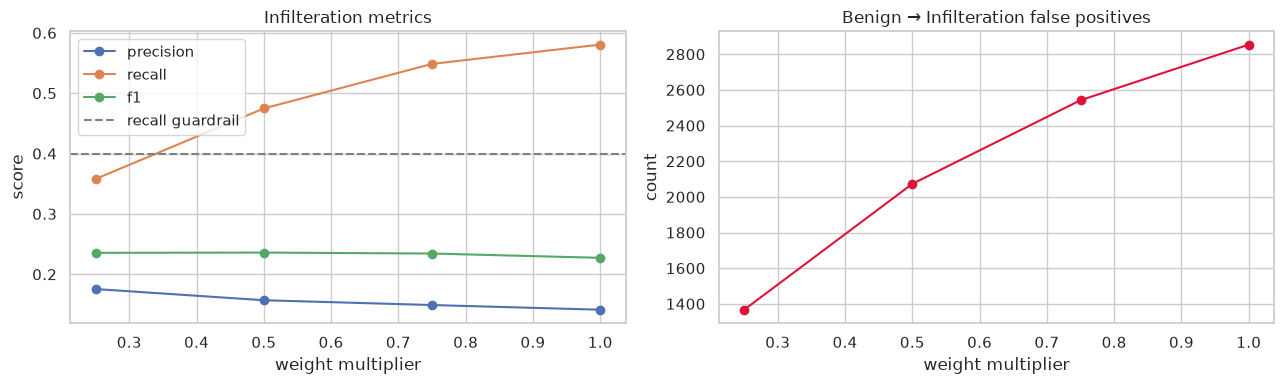

Saved: /home/jovyan/work/network-classification/outputs/v4/v4_weight_tradeoff.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_df = summary.sort_values("inf_multiplier")
axes[0].plot(plot_df["inf_multiplier"], plot_df["infilteration_precision"], marker="o", label="precision")
axes[0].plot(plot_df["inf_multiplier"], plot_df["infilteration_recall"], marker="o", label="recall")
axes[0].plot(plot_df["inf_multiplier"], plot_df["infilteration_f1"], marker="o", label="f1")
axes[0].axhline(MIN_INFILTRATION_RECALL, color="gray", linestyle="--", label="recall guardrail")
axes[0].set(title="Infilteration metrics", xlabel="weight multiplier", ylabel="score")
axes[0].legend()

axes[1].plot(plot_df["inf_multiplier"], plot_df["benign_to_infilteration_fp"], marker="o", color="crimson")
axes[1].set(title="Benign → Infilteration false positives", xlabel="weight multiplier", ylabel="count")
plt.tight_layout()
tradeoff_path = OUTPUT_DIR / "v4_weight_tradeoff.png"
fig.savefig(tradeoff_path, dpi=140, bbox_inches="tight")
plt.show()
print("Saved:", tradeoff_path)


## 8. Champion 전체 샘플 재학습 및 Test 예측

모델 선택에는 고정 Validation을 사용하고, 최종 제출 모델은 선택된 설정으로 25만 샘플 전체를 다시 학습합니다.


In [12]:
final_pipeline = clone(best_pipeline)
final_started = time.time()
with mlflow.start_run(run_name=f"{HYPOTHESIS_ID}_champion_full_refit") as final_run:
    mlflow.set_tags({
        "project": PROJECT_NAME,
        "hypothesis_id": HYPOTHESIS_ID,
        "hypothesis": HYPOTHESIS,
        "stage": "full_sample_refit",
        "selected_variant": best_name,
    })
    mlflow.log_params({
        "selected_variant": best_name,
        "train_rows": len(X),
        "inf_weight_multiplier": best_result["inf_multiplier"],
        "source_validation_run_id": best_result["run_id"],
    })
    final_pipeline.fit(X, y)
    mlflow.log_metric("train_seconds", time.time() - final_started)
    mlflow.sklearn.log_model(
        final_pipeline, name="model",
        serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
    )
    final_run_id = final_run.info.run_id

print("Full refit run_id:", final_run_id)


2026/08/15 15:05:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v4_champion_full_refit at: http://mlflow:5000/#/experiments/3/runs/358985b7a0c949489aaa4639dbb76fcf
🧪 View experiment at: http://mlflow:5000/#/experiments/3
Full refit run_id: 358985b7a0c949489aaa4639dbb76fcf


In [13]:
def load_full_parquet(path: Path):
    with duckdb.connect() as con:
        return con.execute(f"SELECT * FROM {parquet_expr(path)}").df()

if TEST_PARQUET is None:
    submission = None
    print("Test 데이터가 없어 제출을 생략합니다")
else:
    test_df = load_full_parquet(TEST_PARQUET)
    print("Loaded test:", test_df.shape)
    print(f"Memory: {test_df.memory_usage(deep=True).sum() / 1024**2:,.1f} MB")
    test_df = add_features(test_df, USE_TEMPORAL_FEATURES)
    if ID_COL not in test_df.columns:
        raise KeyError(f"Test 데이터에 {ID_COL!r}가 없습니다")
    test_ids = test_df[ID_COL].copy()
    X_test = test_df.drop(
        columns=[ID_COL, TARGET, *DROP_COLS], errors="ignore"
    )
    missing_features = sorted(set(X.columns) - set(X_test.columns))
    extra_features = sorted(set(X_test.columns) - set(X.columns))
    if missing_features or extra_features:
        raise ValueError(f"Train/Test feature mismatch: missing={missing_features}, extra={extra_features}")
    X_test = X_test[X.columns]
    for column in cat_features:
        X_test[column] = X_test[column].astype("string")
    test_pred = final_pipeline.predict(X_test)
    submission = pd.DataFrame({ID_COL: test_ids, TARGET: test_pred}).set_index(ID_COL)
    submission_path = OUTPUT_DIR / "submission_v4.csv"
    submission.to_csv(submission_path, encoding="utf-8-sig")
    print("Saved:", submission_path, submission.shape)
    display(submission[TARGET].value_counts().to_frame("count"))


Loaded test: (1159701, 43)


Memory: 498.8 MB


Saved: /home/jovyan/work/network-classification/outputs/v4/submission_v4.csv (1159701, 1)


,count
Label,
Benign,744472
DDOS,168608
DoS,93788
Brute Force,89846
Infilteration,62987


## 9. 결과 검증 및 가설 판정

In [14]:
if submission is not None:
    checks = {
        "rows": int(len(submission)),
        "expected_rows": int(test_rows),
        "label_missing": int(submission[TARGET].isna().sum()),
        "duplicate_id": int(submission.index.duplicated().sum()),
        "unknown_labels": sorted(set(submission[TARGET]) - set(classes)),
    }
    print("Submission checks:", checks)
    assert checks["rows"] == checks["expected_rows"]
    assert checks["label_missing"] == 0
    assert checks["duplicate_id"] == 0
    assert not checks["unknown_labels"]

hypothesis_supported = (
    best_result["inf_multiplier"] < 1.0
    and best_result["metrics"]["benign_to_infilteration_fp"]
        < baseline["metrics"]["benign_to_infilteration_fp"]
    and best_result["metrics"]["infilteration_recall"] >= MIN_INFILTRATION_RECALL
    and best_result["metrics"]["weighted_f1_attacks"]
        >= baseline["metrics"]["weighted_f1_attacks"]
)

print("Hypothesis supported:", hypothesis_supported)
print("Selected multiplier :", best_result["inf_multiplier"])
print("Summary CSV         :", summary_path)
print("Final MLflow run    :", final_run_id)


Submission checks: {'rows': 1159701, 'expected_rows': 1159701, 'label_missing': 0, 'duplicate_id': 0, 'unknown_labels': []}
Hypothesis supported: True
Selected multiplier : 0.5
Summary CSV         : /home/jovyan/work/network-classification/outputs/v4/v4_weight_sweep_summary.csv
Final MLflow run    : 358985b7a0c949489aaa4639dbb76fcf
